In [117]:
from evo.core import metrics
from evo.core.units import Unit

from evo.tools import log
log.configure_logging(verbose=True, debug=True, silent=False)

import pprint
import numpy as np

from evo.tools import plot
import matplotlib.pyplot as plt

# temporarily override some package settings
# from evo.tools.settings import SETTINGS
# SETTINGS.plot_usetex = False

# plot.apply_settings(SETTINGS)
%matplotlib inline
# %matplotlib notebook

[DEBUG][2026-03-10 13:53:32,583][log.configure_logging():121]
System info:
Python 3.12.12
Linux-6.17.0-14-generic-x86_64-with-glibc2.39
icta@icta-dev



In [118]:
from evo.tools import file_interface
from rosbags.rosbag2 import Reader as Rosbag2Reader

# Read reference trajectory from bag
# Use ZED SDK pose as reference 
with Rosbag2Reader("../bag/alpha_test_zed_005/alpha_test_zed_005_0.mcap") as reader:
    traj_ref = file_interface.read_bag_trajectory(reader, "/zed/zed_node/pose_with_covariance")

# Read estimated trajectory from DA3 Streaming
est_file = "../bag/alpha_test_zed_005/da3/2/camera_poses_tum.txt"
traj_est = file_interface.read_tum_trajectory_file(est_file)

print(traj_ref)
print(traj_est)


[DEBUG][2026-03-10 13:53:33,293][file_interface.read_bag_trajectory():384]
Loaded 2283 geometry_msgs/msg/PoseWithCovarianceStamped messages of topic: /zed/zed_node/pose_with_covariance
[DEBUG][2026-03-10 13:53:33,882][file_interface.read_tum_trajectory_file():130]
Loaded 463 stamps and poses from: ../bag/alpha_test_zed_005/da3/2/camera_poses_tum.txt
2283 poses, 35.481m path length, 172.761s duration
463 poses, 52.424m path length, 172.426s duration


In [119]:
from evo.core import sync

max_diff = 0.01

traj_ref, traj_est = sync.associate_trajectories(traj_ref, traj_est, max_diff)

[DEBUG][2026-03-10 13:53:33,892][sync.associate_trajectories():120]
Found 463 of max. 463 possible matching timestamps between...
	first trajectory
and:	second trajectory
..with max. time diff.: 0.01 (s) and time offset: 0.0 (s).


In [120]:

import copy

traj_est_aligned = copy.deepcopy(traj_est)
traj_est_aligned.align(traj_ref, correct_scale=True, correct_only_scale=False)

[DEBUG][2026-03-10 13:53:33,896][trajectory.align():268]
Aligning using Umeyama's method... (with scale correction)
[DEBUG][2026-03-10 13:53:33,898][trajectory.align():284]
Rotation of alignment:
[[-0.99695874  0.01425321 -0.07661663]
 [ 0.07510805 -0.08648609 -0.99341781]
 [-0.02078567 -0.99615109  0.08515253]]
Translation of alignment:
[1.58396008 2.88408961 0.23118065]
[DEBUG][2026-03-10 13:53:33,899][trajectory.align():288]
Scale correction: 0.6516934821467785


(array([[-0.99695874,  0.01425321, -0.07661663],
        [ 0.07510805, -0.08648609, -0.99341781],
        [-0.02078567, -0.99615109,  0.08515253]]),
 array([1.58396008, 2.88408961, 0.23118065]),
 np.float64(0.6516934821467785))

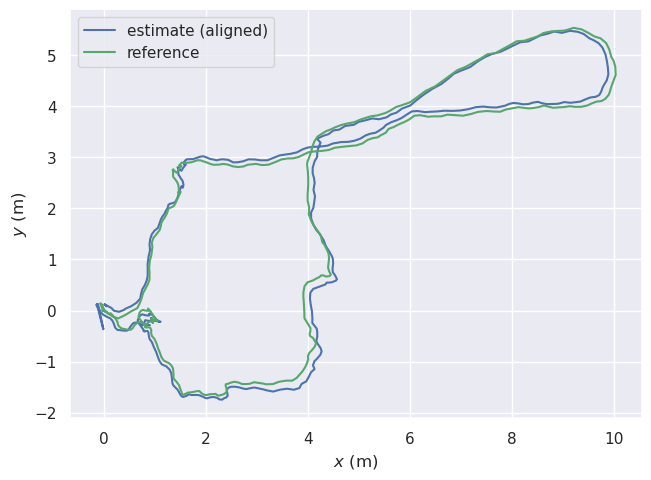

In [121]:
fig = plt.figure()
traj_by_label = {
    "estimate (aligned)": traj_est_aligned,
    "reference": traj_ref
}
plot.trajectories(fig, traj_by_label, plot.PlotMode.xy)
plt.show()

In [122]:
pose_relation = metrics.PoseRelation.rotation_angle_deg
use_aligned_trajectories = True

if use_aligned_trajectories:
    data = (traj_ref, traj_est_aligned) 
else:
    data = (traj_ref, traj_est)

In [123]:
ape_metric = metrics.APE(pose_relation)
ape_metric.process_data(data)

ape_stat = ape_metric.get_statistic(metrics.StatisticsType.rmse)
print(ape_stat)

[DEBUG][2026-03-10 13:53:34,029][metrics.process_data():484]
Compared 463 absolute pose pairs.
[DEBUG][2026-03-10 13:53:34,029][metrics.process_data():485]
Calculating APE for rotation angle in degrees pose relation...
120.34849325918378


In [124]:
ape_stats = ape_metric.get_all_statistics()
pprint.pprint(ape_stats)

{'max': np.float64(142.9322671497906),
 'mean': 120.31756372054409,
 'median': np.float64(120.65501130667742),
 'min': np.float64(111.068316777678),
 'rmse': 120.34849325918378,
 'sse': np.float64(6705980.801176937),
 'std': 2.7283126852727886}


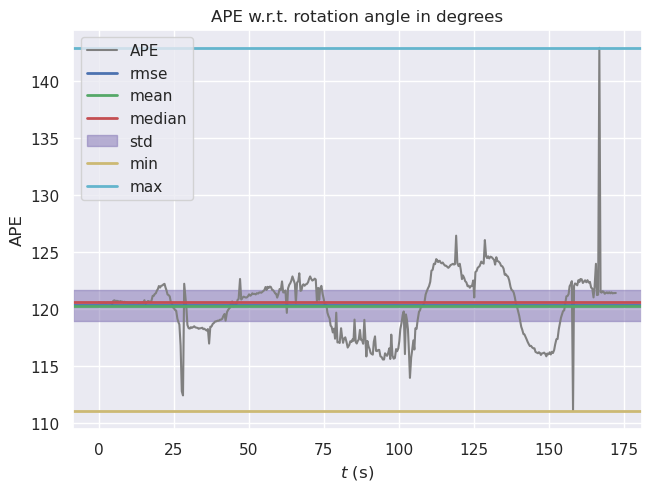

In [125]:
seconds_from_start = [t - traj_est.timestamps[0] for t in traj_est.timestamps]
fig = plt.figure()
plot.error_array(fig.gca(), ape_metric.error, x_array=seconds_from_start,
                 statistics={s:v for s,v in ape_stats.items() if s != "sse"},
                 name="APE", title="APE w.r.t. " + ape_metric.pose_relation.value, xlabel="$t$ (s)")
plt.show()

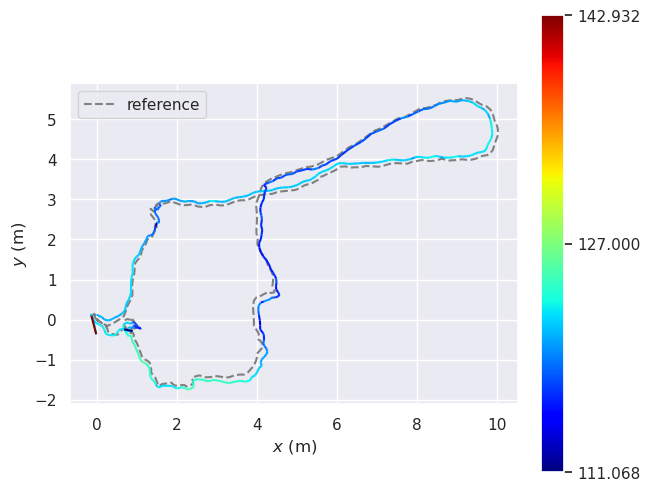

In [126]:
plot_mode = plot.PlotMode.xy
fig = plt.figure()
ax = plot.prepare_axis(fig, plot_mode)
plot.traj(ax, plot_mode, traj_ref, '--', "gray", "reference")
plot.traj_colormap(ax, traj_est_aligned if use_aligned_trajectories else traj_est, ape_metric.error, 
                   plot_mode, min_map=ape_stats["min"], max_map=ape_stats["max"])
ax.legend()
plt.show()



# RPE

In [127]:
pose_relation = metrics.PoseRelation.translation_part

# normal mode
delta = 1
delta_unit = Unit.frames

# all pairs mode
all_pairs = False  # activate

In [128]:
data = (traj_ref, traj_est_aligned)

rpe_metric = metrics.RPE(pose_relation=pose_relation, delta=delta, delta_unit=delta_unit, all_pairs=all_pairs)
rpe_metric.process_data(data)

[DEBUG][2026-03-10 13:53:34,411][metrics.id_pairs_from_delta():555]
Found 462 pairs with delta 1 (frames) among 463 poses using consecutive pairs.
[DEBUG][2026-03-10 13:53:34,417][metrics.process_data():362]
Compared 462 relative pose pairs, delta = 1 (frames) with consecutive pairs.
[DEBUG][2026-03-10 13:53:34,417][metrics.process_data():368]
Calculating RPE for translation part pose relation...


In [129]:
rpe_stat = rpe_metric.get_statistic(metrics.StatisticsType.rmse)
print(rpe_stat)

0.13468115239978523


In [130]:
rpe_stats = rpe_metric.get_all_statistics()
pprint.pprint(rpe_stats)

{'max': np.float64(0.5681900875299579),
 'mean': 0.10734211705637023,
 'median': np.float64(0.10191470680980934),
 'min': np.float64(0.0011099042065483848),
 'rmse': 0.13468115239978523,
 'sse': np.float64(8.380223919021187),
 'std': 0.0813429942748033}


In [131]:
# important: restrict data to delta ids for plot
import copy
traj_ref_plot = copy.deepcopy(traj_ref)
traj_est_plot = copy.deepcopy(traj_est_aligned)
traj_ref_plot.reduce_to_ids(rpe_metric.delta_ids)
traj_est_plot.reduce_to_ids(rpe_metric.delta_ids)
seconds_from_start = [t - traj_est_aligned.timestamps[0] for t in traj_est_aligned.timestamps[1:]]

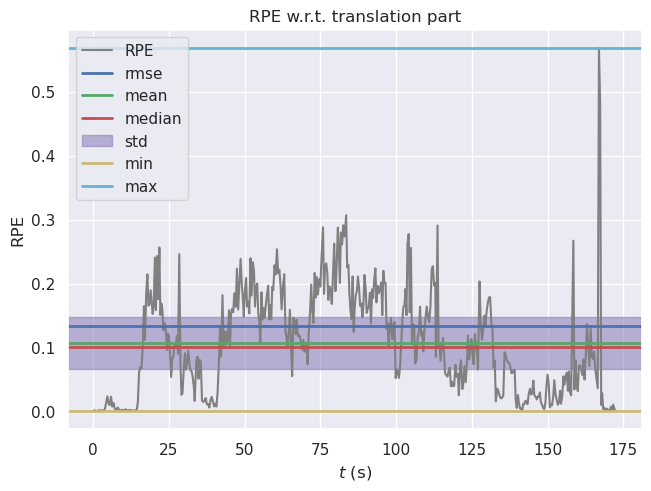

In [132]:

fig = plt.figure()
plot.error_array(fig.gca(), rpe_metric.error, x_array=seconds_from_start,
                 statistics={s:v for s,v in rpe_stats.items() if s != "sse"},
                 name="RPE", title="RPE w.r.t. " + rpe_metric.pose_relation.value, xlabel="$t$ (s)")
plt.show()

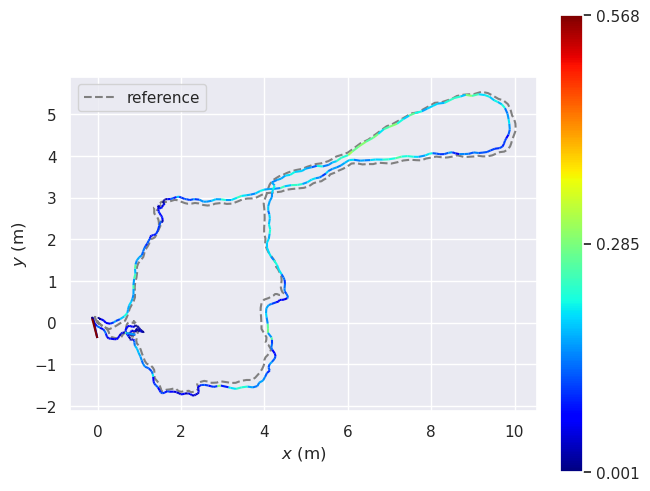

In [133]:
plot_mode = plot.PlotMode.xy
fig = plt.figure()
ax = plot.prepare_axis(fig, plot_mode)
plot.traj(ax, plot_mode, traj_ref_plot, '--', "gray", "reference")
plot.traj_colormap(ax, traj_est_plot, rpe_metric.error, plot_mode, min_map=rpe_stats["min"], max_map=rpe_stats["max"])
ax.legend()
plt.show()